<a href="https://colab.research.google.com/github/ProdhaturiPraneth/Sudoku-Solver/blob/main/maskdetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/maskdetect.zip" -d data

In [ ]:
!ls data

data


In [ ]:
import cv2, os, numpy as np

In [ ]:
def load_images(folder, label, size=(128, 128)):
    data, labels = [], []
    for fname in os.listdir(folder):
        img_path = os.path.join(folder, fname)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # 1. Convert to Grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # 2. Resize to 64x64 (4,096 features)
        resized = cv2.resize(gray, size)

        # Append original image
        data.append(resized.flatten())
        labels.append(label)

        # 3. Data Augmentation: Horizontal Flip
        flipped = cv2.flip(resized, 1)  # 1 = horizontal flip
        data.append(flipped.flatten())
        labels.append(label)

    return data, labels

In [ ]:
mask_data, mask_labels = load_images('data/data/with_mask', 1)
nomask_data, nomask_labels = load_images('data/data/without_mask', 0)

In [ ]:
X = np.array(mask_data + nomask_data, dtype=np.float64)
y = np.array(mask_labels + nomask_labels)

In [ ]:
X /= 255.0

In [ ]:
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

In [ ]:
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
def initialize_weights(dim):
    W = np.zeros(dim)
    b = 0.0
    return W, b

In [ ]:
def compute_loss_and_grads(W, b, X, y):
    m = X.shape[0]

    # Forward pass
    z = X.dot(W) + b
    a = sigmoid(z)

    # Compute loss
    loss = -np.mean(y * np.log(a + 1e-8) + (1 - y) * np.log(1 - a + 1e-8))

    # Compute gradients
    dW = (1 / m) * X.T.dot(a - y)
    db = (1 / m) * np.sum(a - y)

    return loss, dW, db

In [ ]:
W, b = initialize_weights(X_train.shape[1])
lr = 0.0001
epochs = 1000

for epoch in range(epochs):
    loss, dW, db = compute_loss_and_grads(W, b, X_train, y_train)
    W -= lr * dW
    b -= lr * db

    # Put the print block INSIDE the loop (indented)
    if epoch % 20 == 0:
        preds = (sigmoid(X_train.dot(W) + b) > 0.5).astype(int)
        acc = np.mean(preds == y_train)
        print(f"epoch {epoch}, loss={loss:.4f}, train_acc={acc:.3f}")

epoch 0, loss=0.6931, train_acc=0.516
epoch 20, loss=0.6899, train_acc=0.581
epoch 40, loss=0.6872, train_acc=0.600
epoch 60, loss=0.6848, train_acc=0.603
epoch 80, loss=0.6828, train_acc=0.606
epoch 100, loss=0.6810, train_acc=0.605
epoch 120, loss=0.6794, train_acc=0.606
epoch 140, loss=0.6780, train_acc=0.607
epoch 160, loss=0.6768, train_acc=0.607
epoch 180, loss=0.6757, train_acc=0.608
epoch 200, loss=0.6746, train_acc=0.608
epoch 220, loss=0.6737, train_acc=0.608
epoch 240, loss=0.6729, train_acc=0.608
epoch 260, loss=0.6721, train_acc=0.608
epoch 280, loss=0.6714, train_acc=0.609
epoch 300, loss=0.6707, train_acc=0.610
epoch 320, loss=0.6701, train_acc=0.612
epoch 340, loss=0.6695, train_acc=0.614
epoch 360, loss=0.6689, train_acc=0.614
epoch 380, loss=0.6684, train_acc=0.614
epoch 400, loss=0.6678, train_acc=0.615
epoch 420, loss=0.6673, train_acc=0.615
epoch 440, loss=0.6669, train_acc=0.616
epoch 460, loss=0.6664, train_acc=0.617
epoch 480, loss=0.6659, train_acc=0.618
epoch 

In [ ]:
val_preds = (sigmoid(X_val.dot(W) + b) > 0.5).astype(int)
val_acc = np.mean(val_preds == y_val)
print(f"Validation Accuracy: {val_acc:.3f}")

Validation Accuracy: 0.625


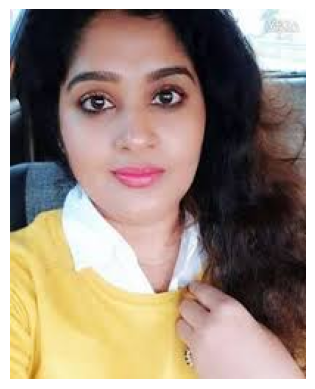

Prediction: No Mask


In [ ]:
import matplotlib.pyplot as plt

def predict(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not load image from {img_path}.")
        return "Error: Image not loaded"

    # Display original RGB photo visually
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    # Preprocess identically to training pipeline:
    # 1. Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # 2. Resize to 64x64 & Flatten (4,096 features)
    img_resized = cv2.resize(gray, (128, 128)).flatten() / 255.0

    # Model inference
    prob = sigmoid(img_resized.dot(W) + b)

    return "Mask" if prob > 0.5 else "No Mask"

# Test prediction
result = predict('data/data/without_mask/without_mask_1740.jpg')
print("Prediction:", result)